## IEEE-CIS Fraud Detection: Dataset Analysis

This notebook **derives from the raw CSVs** every claim in the Phase 1 dataset
characteristics table

| Experiment | Question it answers | Production decision it drives |
|---|---|---|
| 1. File inventory | Rows / columns / join key per file | Schema contract for Bronze ingestion |
| 2. Class balance | What is the true fraud rate? | Metric choice + expectation setting |
| 3. Missingness | How null is null? | Imputation strategy, feature pruning |
| 4. `TransactionDT` | Is it a timestamp? | Temporal split + time-based features |
| 5. Identity coverage | How many transactions have identity? | JOIN type, null-safe feature design |
| 6. Anonymised features | What is `V*` / `id_*`? | Validation strategy for opaque features |
| 7. Categorical cardinality | How wide do categoricals get? | Encoding strategy (hash/bucket vs one-hot) |
| 8. Train vs test | Random split or temporal? | Backtest design |
| 9. Verdict table | Measured vs claimed | Sign-off on the Phase 1 spec |

**Source:** `ml/data/` — the four Kaggle CSVs from
[ieee-fraud-detection](https://www.kaggle.com/c/ieee-fraud-detection/data)

---
## Dataset Column Reference

This section documents every column group in both raw CSVs, its meaning, data type, and representative sample values taken directly from the training data.

---

### `train_transaction.csv` — 590,540 rows × 394 columns

#### 1. Core identifiers & label

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `TransactionID` | int32 | Unique identifier for each transaction. Join key to `train_identity`. | 2987000, 2987001, 2987002 |
| `isFraud` | int8 (0/1) | **Target label.** 1 = fraudulent, 0 = legitimate. ~3.5 % positive rate. | 0, 0, 1 |

#### 2. Transaction timing — `TransactionDT`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `TransactionDT` | int32 | Seconds elapsed since a fixed (undisclosed) reference date — **not** a Unix timestamp. Spans ≈ 6 months (0 … 15,811,131 s). Used to build temporal train/test splits and time-based features (hour-of-day, day-of-week). | 86400, 86401, 86469, 172800 |

#### 3. Transaction amount — `TransactionAmt`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `TransactionAmt` | float32 | Dollar value of the transaction (USD). Ranges from < $1 to > $30,000. Highly right-skewed; log-transform is standard. | 68.5, 29.0, 59.0, 117.0, 2000.0 |

#### 4. Product code — `ProductCD`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `ProductCD` | object (categorical) | Category of the purchased product/service. One of five anonymised codes. The distribution and fraud rate differ significantly across codes (e.g., `W` is the most common; `S` has the highest fraud rate). | W, H, C, R, S |

#### 5. Payment card features — `card1` … `card6`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `card1` | int/object | Card issuer or product identifier (encoded integer). High cardinality (~13,000 unique). Often used as a proxy for the card account. | 13926, 2755, 4663 |
| `card2` | float32 | Secondary card attribute (e.g., BIN prefix group). ~500 unique values; ≈1.5 % null. | 404.0, 490.0, 567.0, 514.0 |
| `card3` | float32 | Tertiary card attribute. Very low cardinality (~114 unique). | 150.0, 117.0, 185.0 |
| `card4` | object | Card network / scheme. | visa, mastercard, discover, american express |
| `card5` | float32 | Card sub-type numeric code. ~119 unique values. | 102.0, 117.0, 142.0, 166.0 |
| `card6` | object | Card funding type. | debit, credit, debit or credit, charge card |

#### 6. Address features — `addr1`, `addr2`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `addr1` | float32 | Billing address ZIP code (encoded). ~300 unique non-null values; ≈11 % null. | 315.0, 325.0, 330.0, 476.0 |
| `addr2` | float32 | Billing country code (encoded). Very low cardinality; predominantly one value (87.0 ≈ US). ≈11 % null. | 87.0, 60.0, 96.0 |

#### 7. Distance features — `dist1`, `dist2`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `dist1` | float32 | Distance (miles) between purchaser ZIP and billing address ZIP. ≈59 % null — only populated when both are known. | 19.0, 287.0, 1331.0, 0.0 |
| `dist2` | float32 | Distance between purchaser ZIP and identity ZIP. Higher missingness than `dist1` (≈94 % null). | 0.0, 5.0, 65.0 |

#### 8. Email domains — `P_emaildomain`, `R_emaildomain`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `P_emaildomain` | object | Email domain of the **purchaser** (payer). ≈16 % null. Top domains: gmail.com, yahoo.com, outlook.com, hotmail.com, anonymous.com. | gmail.com, yahoo.com, outlook.com, hotmail.com |
| `R_emaildomain` | object | Email domain of the **recipient** (payee / merchant). ≈40 % null; often a business domain. | gmail.com, hotmail.com, protonmail.com |

#### 9. Count features — `C1` … `C14`

These columns count how many times a given attribute (card, address, email, …) has been seen across the dataset up to the transaction time. They are strong fraud signals because fraudsters reuse stolen credentials.

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `C1` | float32 | Count of cards associated with the billing address. | 1.0, 2.0, 4.0 |
| `C2` | float32 | Count of cards used with the purchaser email. | 1.0, 5.0, 8.0 |
| `C3` | float32 | Count of a third attribute (exact definition anonymised). | 0.0, 1.0, 2.0 |
| `C4` | float32 | Count feature 4. | 0.0, 1.0 |
| `C5` | float32 | Count feature 5. | 0.0, 1.0, 4.0 |
| `C6` | float32 | Count feature 6. | 1.0, 4.0, 6.0 |
| `C7`–`C14` | float32 | Additional count features following the same pattern. `C13` and `C14` tend to be the highest-valued (can exceed 2,500 for repeat users). | varies |

#### 10. Time-delta features — `D1` … `D15`

These capture the number of **days** between the current transaction and some prior event (previous purchase on the same card, previous use of the same device, etc.). High values may indicate dormant accounts suddenly reactivated — a common fraud pattern.

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `D1` | float32 | Days since the card was first seen. Range 0–640. ≈0.5 % null. | 0.0, 1.0, 14.0, 365.0 |
| `D2` | float32 | Days since last transaction on this card. ≈47 % null. | 0.0, 1.0, 30.0 |
| `D3` | float32 | Days-delta 3 (definition anonymised). ≈54 % null. | 0.0, 1.0, 7.0 |
| `D4`–`D15` | float32 | Further time-delta features. Missingness varies from ≈0 % (`D10`) to ≈97 % (`D7`, `D12`). | varies |

#### 11. Match flags — `M1` … `M9`

Boolean-style flags (True / False / NaN) indicating whether two pieces of information **match** (e.g., does the name on the card match the name on the account?).

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `M1` | object (T/F) | Name-on-card matches purchaser name. ≈46 % null. | T, F |
| `M2` | object (T/F) | Additional match flag 2. ≈46 % null. | T, F |
| `M3` | object (T/F) | Additional match flag 3. ≈46 % null. | T, F |
| `M4` | object | Anonymised categorical match status. | M0, M1, M2 |
| `M5`–`M9` | object (T/F) | Further match flags. `M5`–`M9` have lower missingness (≈9 %). | T, F |

#### 12. Vesta engineered features — `V1` … `V339`

339 anonymised features engineered by Vesta Corporation's fraud-team from their internal graph of transactions, devices, and accounts. Each feature is a float that captures some higher-order relationship (e.g., velocity counts, behavioural distances, aggregated statistics). Their exact definitions are proprietary and undisclosed.

| Column group | Type | Meaning | Missingness |
|---|---|---|---|
| `V1`–`V11` | float32 | First block — related to card linkage counts. | Low (< 5 %) |
| `V12`–`V34` | float32 | Second block — transaction amount aggregations. | Low |
| `V35`–`V52` | float32 | Third block. | Moderate (20–40 %) |
| `V53`–`V74` | float32 | Fourth block. | Low–Moderate |
| `V75`–`V94` | float32 | Fifth block. | Moderate |
| `V95`–`V137` | float32 | Sixth block — velocity / recency signals. | High (40–70 %) |
| `V138`–`V166` | float32 | Seventh block. | Very high (> 80 %) |
| `V167`–`V278` | float32 | Eighth–ninth blocks. | Very high (> 85 %) |
| `V279`–`V321` | float32 | Tenth block. | Very high (> 90 %) |
| `V322`–`V339` | float32 | Eleventh block. | Very high (> 95 %) |

> **Note:** Because V features are opaque, validation relies on distribution shape (all-positive? bounded 0–1?) and cross-validation fold stability rather than business logic.

---

### `train_identity.csv` — 144,233 rows × 41 columns

Only **~24 % of transactions** have a matching identity record (left-join on `TransactionID`). Features here are richer digital fingerprints captured by Vesta at the time of purchase.

#### 13. Numeric identity features — `id_01` … `id_11`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `id_01` | float32 | Security score or login-related numeric (signed). Likely measures authentication confidence or device risk. | 0.0, -5.0, -10.0 |
| `id_02` | float32 | Large-valued numeric — possibly device fingerprint hash bucket or session duration in ms. | 70787.0, 98945.0, 191631.0 |
| `id_03` | float32 | Numeric identity feature 3. High missingness (≈74 %). | 0.0, 1.0 |
| `id_04` | float32 | Numeric identity feature 4. High missingness (≈74 %). | 0.0, -1.0 |
| `id_05` | float32 | Numeric identity feature 5. Moderate missingness (≈47 %). | 0.0, 1.0, 2.0 |
| `id_06` | float32 | Numeric identity feature 6. Moderate missingness (≈47 %). | -5.0, 0.0, -6.0 |
| `id_07`–`id_09` | float32 | Further numeric features. Very high missingness (> 90 %). | 0.0, varies |
| `id_10` | float32 | Numeric identity feature 10. ≈74 % null. | 0.0, -1.0 |
| `id_11` | float32 | Numeric — possibly a browser/screen metric. ≈1 % null. | 100.0 |

#### 14. Categorical identity features — `id_12` … `id_38`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `id_12` | object | Identity check result 12 (binary). | Found, NotFound |
| `id_13` | float32 | Numeric (possibly screen resolution component or browser version). ≈20 % null. | 49.0, 52.0 |
| `id_14` | float32 | Timezone offset from UTC in minutes. ≈16 % null. | -480.0, -300.0 |
| `id_15` | object | Whether the device/identity is **new** to the system or was previously seen. | New, Found, Unknown |
| `id_16` | object | Identity check result 16 (binary). ≈17 % null. | Found, NotFound |
| `id_17` | float32 | Numeric identity feature 17. ≈1 % null. | 121.0, 166.0, 225.0 |
| `id_18` | float32 | Numeric identity feature 18. ≈75 % null. | 15.0, 0.0 |
| `id_19` | float32 | Numeric identity feature 19. ≈1 % null. | 410.0, 529.0, 542.0 |
| `id_20` | float32 | Numeric identity feature 20. ≈1 % null. | 142.0, 500.0, 507.0, 575.0 |
| `id_21`–`id_26` | float32 | Numeric features. Very high missingness (> 95 %). | 0.0, varies |
| `id_27`–`id_29` | object | Categorical features. Moderate missingness. | Found, NotFound, New |
| `id_30` | object | Operating system name + version string. ≈10 % null. | Android 7.0, iOS 11.1.2, Mac OS X 10_11_6, Windows |
| `id_31` | object | Browser name + version string. ≈2 % null. | samsung browser 6.2, mobile safari 11.0, chrome 62.0 |
| `id_32` | float32 | Screen colour depth (bits). ≈19 % null. | 24.0, 32.0 |
| `id_33` | object | Screen resolution string (width x height). ≈20 % null. | 2220x1080, 1334x750, 1280x800 |
| `id_34` | object | Identity match status string. ≈20 % null. | match_status:2, match_status:1 |
| `id_35` | object (T/F) | Boolean identity flag 35. ≈1 % null. | T, F |
| `id_36` | object (T/F) | Boolean identity flag 36. ≈1 % null. | T, F |
| `id_37` | object (T/F) | Boolean identity flag 37. ≈1 % null. | T, F |
| `id_38` | object (T/F) | Boolean identity flag 38. ≈1 % null. | T, F |

#### 15. Device features — `DeviceType`, `DeviceInfo`

| Column | Type | Meaning | Sample values |
|---|---|---|---|
| `DeviceType` | object | High-level device category. Very low cardinality. | mobile, desktop |
| `DeviceInfo` | object | Specific device model / OS string. High cardinality (~1,800 unique). ≈18 % null. | SAMSUNG SM-G892A Build/NRD90M, iOS Device, Windows, MacOS |

---

> **Column naming quirk:** `test_identity.csv` uses hyphens (`id-01`) while `train_identity.csv` uses underscores (`id_01`). The loader normalises all names to underscores on read — see the `normalise_columns()` helper in the Setup cell.


## 0. Setup

`train_transaction.csv` is 590,540 x 394. Read naively as `float64` it is
~1.9 GB before object columns. We instead infer a dtype map once from a sample
and pass it to `read_csv`, so the wide numeric block is materialised directly
as `float32` and never doubles. Everything below is ordinary pandas — no Spark
required — which keeps this notebook runnable on a laptop.

In [1]:
from __future__ import annotations

import gc
import json
import re
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    get_ipython()  # noqa: F821
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False
if not IN_NOTEBOOK:
    matplotlib.use("Agg")

# Resolve ml/data whether the notebook is run from notebook/ or the repo root.
HERE = Path.cwd()
DATA_DIR = next(
    (p / "ml" / "data" for p in (HERE, *HERE.parents) if (p / "ml" / "data").is_dir()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate ml/data — run from the repo or a subdirectory of it.")

REPO_ROOT = DATA_DIR.parent.parent
OUT_DIR = REPO_ROOT / "notebook" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "train_transaction": DATA_DIR / "train_transaction.csv",
    "train_identity": DATA_DIR / "train_identity.csv",
    "test_transaction": DATA_DIR / "test_transaction.csv",
    "test_identity": DATA_DIR / "test_identity.csv",
}

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print(f"data dir : {DATA_DIR}")
print(f"outputs  : {OUT_DIR}")
for name, path in FILES.items():
    status = f"{path.stat().st_size / 1e6:8.1f} MB" if path.exists() else "   MISSING"
    print(f"  {name:20s} {status}")/



data dir : d:\code file\Project-2-Real-time-fraudlent detection\ml\data
outputs  : d:\code file\Project-2-Real-time-fraudlent detection\notebook\outputs
  train_transaction       683.4 MB
  train_identity           26.5 MB
  test_transaction        613.2 MB
  test_identity            25.8 MB


### Chart style

In [2]:
INK = "#0b0b0b"        # primary text
INK_2 = "#52514e"      # secondary text
MUTED = "#a8a7a1"      # grid / rules
SURFACE = "#fcfcfb"    # chart surface
BLUE = "#2a78d6"       # categorical slot 1
ORANGE = "#eb6834"     # categorical slot 2

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": MUTED, "grid.alpha": 0.35, "grid.linewidth": 0.6,
    "legend.frameon": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 16,
})


def finish(ax, title, subtitle="", grid_axis="y"):
    """Apply the shared title/grid treatment."""
    ax.set_title(title, loc="left")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=INK_2, va="bottom")
    ax.grid(axis=grid_axis, zorder=0)
    ax.set_axisbelow(True)
    return ax


def save(fig, name):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"saved -> notebook/outputs/{name}.png")

### Memory-aware loader

Two passes: infer object vs numeric from a 200k-row sample (unioned with the
known-categorical list, so a column that is all-null early in the file is not
mis-typed), then read the full file with that dtype map.

In [3]:
# Columns documented as categorical by the competition organisers. Unioned with
# sample inference so an all-null-in-sample column can't be forced to float32.
KNOWN_CATEGORICAL = {
    "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "P_emaildomain", "R_emaildomain",
    *[f"M{i}" for i in range(1, 10)],
    *[f"id_{i:02d}" for i in range(12, 39)],
    "DeviceType", "DeviceInfo",
}


def normalise_columns(df):
    """test_identity.csv ships `id-01`; train_identity.csv ships `id_01`.

    A real ingestion gotcha: joining the two without this rename silently
    produces two disjoint column sets. Bronze normalises on write.
    """
    return df.rename(columns=lambda c: re.sub(r"^id-(\d+)$", r"id_\1", c))


def load(path, usecols=None, sample_rows=200_000):
    sample = normalise_columns(
        pd.read_csv(path, nrows=sample_rows, usecols=usecols, low_memory=False))
    obj = set(sample.select_dtypes(include="object").columns)
    dtypes = {}
    for col in sample.columns:
        if col == "TransactionID":
            dtypes[col] = "int32"
        elif col == "isFraud":
            dtypes[col] = "int8"
        elif col == "TransactionDT":
            dtypes[col] = "int32"
        elif col in obj or (col in KNOWN_CATEGORICAL and sample[col].isna().all()):
            dtypes[col] = "object"
        else:
            dtypes[col] = "float32"
    # The dtype map is keyed on normalised names; map back to on-disk names.
    on_disk = pd.read_csv(path, nrows=0, usecols=usecols).columns
    back = {re.sub(r"^id-(\d+)$", r"id_\1", c): c for c in on_disk}
    disk_dtypes = {back[k]: v for k, v in dtypes.items() if k in back}
    try:
        df = pd.read_csv(path, dtype=disk_dtypes, usecols=usecols, engine="c")
    except ValueError as exc:  # a late-file string in a column sampled as numeric
        print(f"  dtype map rejected ({exc}); falling back to inference")
        df = pd.read_csv(path, usecols=usecols, low_memory=False)
    return normalise_columns(df)


def mem_mb(df):
    return df.memory_usage(deep=True).sum() / 1e6

---
## Experiment 1 — File inventory: rows, columns, join key

**Claim under test:** 590,540x394 / 144,233x41 / 506,691x393 / 141,907x41, all
joined on `TransactionID`.

Row counts come from a buffered byte scan rather than a DataFrame — counting
506,691 rows should not cost 1.8 GB of RAM.

In [4]:
def count_rows(path):
    """Count data rows (excluding header) without materialising the file."""
    with path.open("rb") as fh:
        n = sum(buf.count(b"\n") for buf in iter(lambda: fh.read(1 << 22), b""))
        fh.seek(-1, 2)
        trailing_newline = fh.read(1) == b"\n"
    return n - (1 if trailing_newline else 0)


inventory = []
for name, path in FILES.items():
    header = pd.read_csv(path, nrows=0)
    cols = normalise_columns(header).columns.tolist()
    inventory.append({
        "file": f"{name}.csv",
        "rows": count_rows(path),
        "columns": len(cols),
        "join_key": "TransactionID" if "TransactionID" in cols else "-",
        "has_label": "isFraud" in cols,
        "size_mb": round(path.stat().st_size / 1e6, 1),
        "hyphenated_ids": any(c.startswith("id-") for c in header.columns),
    })

inventory_df = pd.DataFrame(inventory)
inventory_df

,file,rows,columns,join_key,has_label,size_mb,hyphenated_ids
0,train_transaction.csv,590540,394,TransactionID,True,683.4,False
1,train_identity.csv,144233,41,TransactionID,False,26.5,False
2,test_transaction.csv,506691,393,TransactionID,False,613.2,False
3,test_identity.csv,141907,41,TransactionID,False,25.8,True


Note the `hyphenated_ids` column: **`test_identity.csv` names its columns
`id-01`...`id-38` while `train_identity.csv` uses `id_01`...`id_38`.** This is a
genuine Kaggle packaging inconsistency, not a reading error, and it is exactly
the kind of defect that silently produces an all-null feature block in
production. Bronze ingestion must normalise on write.

In [5]:
raw_test_cols = set(pd.read_csv(FILES["test_identity"], nrows=0).columns)
raw_train_cols = set(pd.read_csv(FILES["train_identity"], nrows=0).columns)
norm_test_cols = set(normalise_columns(pd.read_csv(FILES["test_identity"], nrows=0)).columns)

print("test_identity  raw header:", sorted(raw_test_cols)[:4], "...")
print("train_identity raw header:", sorted(raw_train_cols)[:4], "...")
print(f"\ncolumn overlap BEFORE normalising: {len(raw_test_cols & raw_train_cols):>3}")
print(f"column overlap AFTER  normalising: {len(norm_test_cols & raw_train_cols):>3}")

test_identity  raw header: ['DeviceInfo', 'DeviceType', 'TransactionID', 'id-01'] ...
train_identity raw header: ['DeviceInfo', 'DeviceType', 'TransactionID', 'id_01'] ...

column overlap BEFORE normalising:   3
column overlap AFTER  normalising:  41


### Load the training pair

Held for experiments 2-7, then released before the test files are touched.

In [6]:
train_tx = load(FILES["train_transaction"])
train_id = load(FILES["train_identity"])

print(f"train_transaction {train_tx.shape}  {mem_mb(train_tx):,.0f} MB in memory")
print(f"train_identity    {train_id.shape}  {mem_mb(train_id):,.0f} MB in memory")
print(f"\nnaive float64 equivalent for train_transaction: "
      f"{train_tx.shape[0] * train_tx.shape[1] * 8 / 1e6:,.0f} MB")

train_transaction (590540, 394)  1,303 MB in memory
train_identity    (144233, 41)  151 MB in memory

naive float64 equivalent for train_transaction: 1,861 MB


---
## Experiment 2 — Class balance

**Claim under test:** ~3.5% fraud (20,663 / 590,540); higher than the
real-world 0.1-0.5%, so production metrics must not be benchmarked against it.

In [7]:
fraud_counts = train_tx["isFraud"].value_counts().sort_index()
n_total = int(fraud_counts.sum())
n_fraud = int(fraud_counts.get(1, 0))
n_legit = int(fraud_counts.get(0, 0))
fraud_rate = n_fraud / n_total

print(f"legitimate      : {n_legit:>10,}")
print(f"fraudulent      : {n_fraud:>10,}")
print(f"total           : {n_total:>10,}")
print(f"fraud rate      : {fraud_rate:>10.4%}")
print(f"imbalance ratio : 1 fraud per {n_legit / n_fraud:,.1f} legitimate")

# The trap this sets: accuracy is useless at this prevalence.
print(f"\naccuracy of a model that predicts 'never fraud': {1 - fraud_rate:.2%}")
print("-> accuracy is meaningless here; Phase 1 scores on PR-AUC and recall @ fixed FPR.")

# Real-world production prevalence is 0.1-0.5%; quantify the optimism.
for real_rate in (0.005, 0.001):
    print(f"dataset prevalence is {fraud_rate / real_rate:>5.1f}x a {real_rate:.1%} production rate")

legitimate      :    569,877
fraudulent      :     20,663
total           :    590,540
fraud rate      :    3.4990%
imbalance ratio : 1 fraud per 27.6 legitimate

accuracy of a model that predicts 'never fraud': 96.50%
-> accuracy is meaningless here; Phase 1 scores on PR-AUC and recall @ fixed FPR.
dataset prevalence is   7.0x a 0.5% production rate
dataset prevalence is  35.0x a 0.1% production rate


saved -> notebook/outputs/01_class_imbalance.png


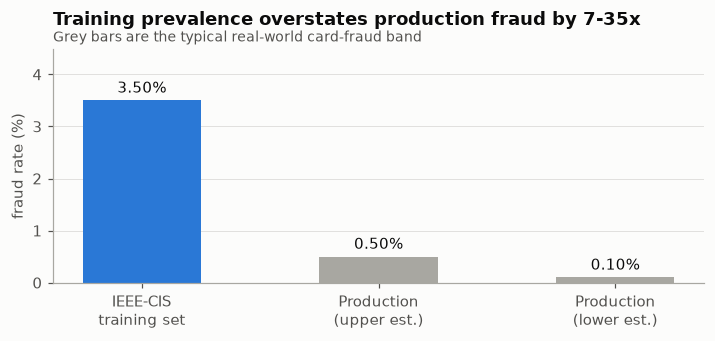

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
labels = ["IEEE-CIS\ntraining set", "Production\n(upper est.)", "Production\n(lower est.)"]
values = [fraud_rate * 100, 0.5, 0.1]
bars = ax.bar(labels, values, width=0.5, color=[BLUE, MUTED, MUTED], zorder=2)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.08, f"{val:.2f}%",
            ha="center", va="bottom", fontsize=10, color=INK)
ax.set_ylabel("fraud rate (%)")
ax.set_ylim(0, max(values) * 1.28)
finish(ax, "Training prevalence overstates production fraud by 7-35x",
       "Grey bars are the typical real-world card-fraud band")
plt.tight_layout()
save(fig, "01_class_imbalance")
plt.show()

---
## Experiment 3 — Missingness

**Claim under test:** many V-columns are 80-99% null; `addr2` ~1.5% null;
email domains ~25% null. Naive imputation would inject noise at that density.

In [9]:
null_rate = train_tx.isna().mean().sort_values(ascending=False)
null_df = null_rate.rename("null_rate").to_frame()
null_df["group"] = np.select(
    [null_df.index.str.fullmatch(r"V\d+"), null_df.index.str.fullmatch(r"C\d+"),
     null_df.index.str.fullmatch(r"D\d+"), null_df.index.str.fullmatch(r"M\d+"),
     null_df.index.str.startswith("card"), null_df.index.str.startswith("addr"),
     null_df.index.str.startswith("dist"), null_df.index.str.contains("emaildomain")],
    ["V", "C", "D", "M", "card", "addr", "dist", "email"], "core")

print("Null rate by column group:\n")
print(null_df.groupby("group")["null_rate"]
      .agg(columns="size", min="min", median="median", max="max")
      .sort_values("median", ascending=False)
      .to_string(float_format=lambda v: f"{v:.2%}"))

Null rate by column group:

       columns    min  median    max
group                               
dist         2 59.65%  76.64% 93.63%
D           15  0.21%  52.47% 93.41%
M            9 28.68%  47.66% 59.35%
V          339  0.00%  47.29% 86.12%
email        2 15.99%  46.37% 76.75%
addr         2 11.13%  11.13% 11.13%
card         6  0.00%   0.27%  1.51%
C           14  0.00%   0.00%  0.00%
core         5  0.00%   0.00%  0.00%


In [10]:
v_nulls = null_df.query("group == 'V'")["null_rate"]
print(f"V columns total                 : {len(v_nulls)}")
print(f"  in the 80-99% null band       : {int(((v_nulls >= 0.80) & (v_nulls < 0.99)).sum())}")
print(f"  >= 50% null                   : {int((v_nulls >= 0.50).sum())}")
print(f"  <  1% null                    : {int((v_nulls < 0.01).sum())}")
print(f"  max null rate                 : {v_nulls.max():.2%}  ({v_nulls.idxmax()})")

print("\nSpecific claims:")
for col in ["addr1", "addr2", "P_emaildomain", "R_emaildomain", "dist1", "dist2"]:
    print(f"  {col:16s} {null_rate[col]:>8.2%} null")

print(f"\nColumns with zero nulls         : {int((null_rate == 0).sum())} / {len(null_rate)}")
print(f"Share of all cells missing      : {train_tx.isna().to_numpy().mean():.2%}")

V columns total                 : 339
  in the 80-99% null band       : 47
  >= 50% null                   : 159
  <  1% null                    : 86
  max null rate                 : 86.12%  (V153)

Specific claims:
  addr1              11.13% null
  addr2              11.13% null
  P_emaildomain      15.99% null
  R_emaildomain      76.75% null
  dist1              59.65% null
  dist2              93.63% null

Columns with zero nulls         : 20 / 394
Share of all cells missing      : 41.07%


saved -> notebook/outputs/02_null_distribution.png


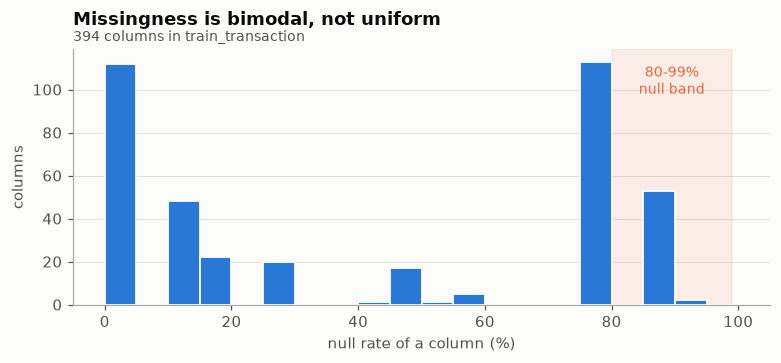

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.hist(null_rate.to_numpy() * 100, bins=np.arange(0, 105, 5), color=BLUE, zorder=2,
        edgecolor=SURFACE, linewidth=1.2)
ax.axvspan(80, 99, color=ORANGE, alpha=0.10, zorder=1)
ax.text(89.5, ax.get_ylim()[1] * 0.94, "80-99%\nnull band", ha="center", va="top",
        fontsize=9, color=ORANGE)
ax.set_xlabel("null rate of a column (%)")
ax.set_ylabel("columns")
finish(ax, "Missingness is bimodal, not uniform",
       f"{len(null_rate)} columns in train_transaction")
plt.tight_layout()
save(fig, "02_null_distribution")
plt.show()

### Nullity blocks

The V-columns do not go missing independently — they arrive in blocks that
share an identical null mask, i.e. whole feature families are present or absent
together. This matters more than the marginal null rate: imputing per column
destroys the block structure, and "which block is present" is itself a feature.

In [12]:
v_cols = [c for c in train_tx.columns if re.fullmatch(r"V\d+", c)]
masks = {}
for col in v_cols:
    key = train_tx[col].isna().to_numpy().tobytes()
    masks.setdefault(key, []).append(col)

blocks = sorted(masks.values(), key=len, reverse=True)
print(f"{len(v_cols)} V-columns collapse into {len(blocks)} distinct null patterns\n")
for i, block in enumerate(blocks[:10], 1):
    rate = train_tx[block[0]].isna().mean()
    example = ", ".join(block[:5]) + (" ..." if len(block) > 5 else "")
    print(f"  block {i:>2}: {len(block):>3} cols @ {rate:>6.2%} null   {example}")
if len(blocks) > 10:
    print(f"  ... and {len(blocks) - 10} smaller blocks")

339 V-columns collapse into 15 distinct null patterns

  block  1:  46 cols @ 77.91% null   V217, V218, V219, V223, V224 ...
  block  2:  43 cols @  0.05% null   V95, V96, V97, V98, V99 ...
  block  3:  32 cols @  0.00% null   V279, V280, V284, V285, V286 ...
  block  4:  31 cols @ 76.36% null   V167, V168, V172, V173, V176 ...
  block  5:  23 cols @ 12.88% null   V12, V13, V14, V15, V16 ...
  block  6:  22 cols @ 13.06% null   V53, V54, V55, V56, V57 ...
  block  7:  20 cols @ 15.10% null   V75, V76, V77, V78, V79 ...
  block  8:  19 cols @ 76.32% null   V169, V170, V171, V174, V175 ...
  block  9:  18 cols @ 28.61% null   V35, V36, V37, V38, V39 ...
  block 10:  18 cols @ 86.12% null   V138, V139, V140, V141, V142 ...
  ... and 5 smaller blocks


---
## Experiment 4 — `TransactionDT` is not a timestamp

**Claim under test:** it is an integer offset in seconds from an undisclosed
reference date, so timestamps must be synthesised before any temporal work.

In [ ]:
dt = train_tx["TransactionDT"]
print(f"dtype            : {dt.dtype}")
print(f"min / max        : {dt.min():,} / {dt.max():,}")
print(f"span             : {(int(dt.max()) - int(dt.min())) / 86400:.1f} days")
print(f"monotonic        : {dt.is_monotonic_increasing}")
print(f"unique values    : {dt.nunique():,} over {len(dt):,} rows")

# Proof it is a relative offset, not epoch seconds: read as epoch it lands in 1970.
print(f"\nif read as Unix epoch seconds -> {pd.to_datetime(int(dt.min()), unit='s')}"
      f" .. {pd.to_datetime(int(dt.max()), unit='s')}   <- implausible")

# The community-established reference date; treated as an assumption, not a fact.
REFERENCE_DATE = pd.Timestamp("2017-11-30")
train_tx["timestamp"] = REFERENCE_DATE + pd.to_timedelta(dt.astype("int64"), unit="s")
print(f"with reference {REFERENCE_DATE.date()}  -> "
      f"{train_tx['timestamp'].min()} .. {train_tx['timestamp'].max()}   <- plausible")

Derived hour-of-day is the sanity check on the *unit*: if `TransactionDT` really
counts seconds, `dt % 86400` must produce a coherent 24-hour cycle. It does — the
fraud rate swings several-fold between its trough and its peak. An integer that
was not time-based would smear flat.

Note what this does **not** prove: the reference *date* only shifts the labels on
the x-axis, not the shape of the curve, so `2017-11-30` remains an unverified
assumption. It is recorded as pipeline metadata for exactly that reason.

In [ ]:
train_tx["hour"] = train_tx["timestamp"].dt.hour
hourly = train_tx.groupby("hour").agg(txns=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
peak_hour = int(hourly["fraud_rate"].idxmax())

trough_hour = int(hourly["fraud_rate"].idxmin())
peak_rate = float(hourly["fraud_rate"].max())
trough_rate = float(hourly["fraud_rate"].min())

print(hourly.assign(fraud_rate=lambda d: d["fraud_rate"].map("{:.2%}".format)).to_string())
print(f"\npeak   : {peak_rate:.2%} at {peak_hour:02d}:00")
print(f"trough : {trough_rate:.2%} at {trough_hour:02d}:00")
print(f"swing  : {peak_rate / trough_rate:.1f}x between trough and peak "
      f"(overall {fraud_rate:.2%})")
print("\nA coherent diurnal cycle of this amplitude only appears if TransactionDT")
print("is genuinely seconds-based -> the unit is confirmed. Hour-of-day is worth")
print("engineering as a feature; the absolute reference date is not needed for it.")

In [ ]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
ax.plot(hourly.index, hourly["fraud_rate"] * 100, color=BLUE, linewidth=2, zorder=3)
ax.axhline(fraud_rate * 100, color=MUTED, linewidth=1, linestyle="--", zorder=2)
ax.text(23.8, fraud_rate * 100, f" overall {fraud_rate:.2%}", va="center", ha="left",
        fontsize=9, color=INK_2)

# Direct-label the two extremes only; a number on every point would be noise.
for hour, rate, dy, va in [(peak_hour, peak_rate, -0.55, "top"),
                           (trough_hour, trough_rate, 0.45, "bottom")]:
    ax.scatter([hour], [rate * 100], s=44, color=BLUE, edgecolor=SURFACE,
               linewidth=2, zorder=4)
    ax.annotate(f"{rate:.1%} at {hour:02d}:00", xy=(hour, rate * 100),
                xytext=(hour + 0.6, rate * 100 + dy), fontsize=9, color=INK, va=va)

ax.set_xlabel("hour of day (derived from TransactionDT)")
ax.set_ylabel("fraud rate (%)")
ax.set_xticks(range(0, 24, 3))
ax.set_xlim(-0.5, 27.5)
ax.set_ylim(0, peak_rate * 100 * 1.20)  # headroom so labels clear the subtitle
finish(ax, f"Fraud rate swings {peak_rate / trough_rate:.1f}x across the derived hour of day",
       "A coherent 24-hour cycle confirms TransactionDT is a seconds offset")
plt.tight_layout()
save(fig, "03_hourly_fraud_rate")
plt.show()

### Consequence: the split must be temporal

With a real time axis, a random split leaks the future into training. Phase 1
splits on time instead.

In [ ]:
cutoff = train_tx["TransactionDT"].quantile(0.80)
tr_mask = train_tx["TransactionDT"] <= cutoff
cutoff_ts = REFERENCE_DATE + pd.to_timedelta(int(cutoff), unit="s")
print(f"80/20 temporal cutoff at DT={int(cutoff):,}  ({cutoff_ts})")
print(f"  train : {tr_mask.sum():>7,} rows   fraud {train_tx.loc[tr_mask, 'isFraud'].mean():.2%}")
print(f"  valid : {(~tr_mask).sum():>7,} rows   fraud {train_tx.loc[~tr_mask, 'isFraud'].mean():.2%}")
print("\nPrevalence drifts between the two windows - a random split would hide that drift.")

---
## Experiment 5 — Identity coverage

**Claim under test:** only ~24% of transactions have an identity record, so the
join must be a LEFT JOIN and identity features are null for ~76% of rows.

In [ ]:
tx_ids = set(train_tx["TransactionID"])
id_ids = set(train_id["TransactionID"])
coverage = len(tx_ids & id_ids) / len(tx_ids)

print(f"transactions            : {len(tx_ids):,}")
print(f"identity records        : {len(id_ids):,}")
print(f"matched                 : {len(tx_ids & id_ids):,}  ({coverage:.2%} coverage)")
print(f"identity without a txn  : {len(id_ids - tx_ids):,}  (identity is a strict subset)")
print(f"duplicate join keys     : tx={train_tx['TransactionID'].duplicated().sum()}, "
      f"id={train_id['TransactionID'].duplicated().sum()}  -> 1:1 join, no fan-out")

In [ ]:
joined = train_tx[["TransactionID", "isFraud"]].merge(train_id, on="TransactionID", how="left")
assert len(joined) == len(train_tx), "LEFT JOIN must not change the row count"

id_feature_cols = [c for c in train_id.columns if c != "TransactionID"]
print(f"rows after LEFT JOIN               : {len(joined):,} (unchanged)")
print(f"identity-column null rate after join: "
      f"{joined[id_feature_cols].isna().mean().mean():.2%} "
      f"(mean across {len(id_feature_cols)} columns)")

has_identity = joined["TransactionID"].isin(id_ids)
rate_with = joined.loc[has_identity, "isFraud"].mean()
rate_without = joined.loc[~has_identity, "isFraud"].mean()
print(f"\nfraud rate WITH identity   : {rate_with:.2%}  ({has_identity.sum():,} rows)")
print(f"fraud rate WITHOUT identity: {rate_without:.2%}  ({(~has_identity).sum():,} rows)")
print(f"lift                       : {rate_with / rate_without:.2f}x")
print("\n-> Identity *presence* is itself predictive. Encode it as an explicit")
print("   `has_identity` flag rather than letting it vanish into null imputation.")

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.2))
groups = [f"Identity present\n{has_identity.sum():,} rows ({coverage:.0%})",
          f"Identity absent\n{(~has_identity).sum():,} rows ({1 - coverage:.0%})"]
vals = [rate_with * 100, rate_without * 100]
bars = ax.bar(groups, vals, width=0.45, color=BLUE, zorder=2)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15, f"{val:.2f}%",
            ha="center", va="bottom", fontsize=10, color=INK)
ax.set_ylabel("fraud rate (%)")
ax.set_ylim(0, max(vals) * 1.28)
finish(ax, "Identity coverage is ~24% - and its absence carries signal",
       "Missingness is informative, so encode it rather than impute it away")
plt.tight_layout()
save(fig, "04_identity_coverage")
plt.show()

---
## Experiment 6 — Anonymised feature blocks

**Claim under test:** `V1-V339` (Vesta engineered) and `id_01-id_38` are
undisclosed, so no domain validation is possible — they can only be treated as
numerics with careful null handling.

In [ ]:
def group_of(col):
    for pattern, label in [(r"V\d+", "V (Vesta engineered)"), (r"C\d+", "C (counting)"),
                           (r"D\d+", "D (timedelta)"), (r"M\d+", "M (match flags)"),
                           (r"id_\d+", "id (identity)"), (r"card\d", "card"),
                           (r"addr\d", "addr"), (r"dist\d", "dist")]:
        if re.fullmatch(pattern, col):
            return label
    return "core"


all_cols = pd.Series(list(train_tx.columns) + id_feature_cols).drop_duplicates()
all_cols = all_cols[~all_cols.isin(["timestamp", "hour"])]  # derived above, not source columns
grouped = (all_cols.groupby(all_cols.map(group_of))
           .agg(["count", lambda s: ", ".join(sorted(s)[:3]) + " ..."]))
grouped.columns = ["columns", "examples"]
print(grouped.sort_values("columns", ascending=False).to_string())

v_present = sorted(int(c[1:]) for c in v_cols)
print(f"\nV range  : V{min(v_present)}-V{max(v_present)}, {len(v_present)} present, "
      f"gaps: {max(v_present) - len(v_present)}")
id_nums = sorted(int(c.split("_")[1]) for c in id_feature_cols if re.fullmatch(r"id_\d+", c))
print(f"id range : id_{min(id_nums):02d}-id_{max(id_nums):02d}, {len(id_nums)} present")

# id_* is a mixed block: numeric below id_12, mostly categorical from id_12 up.
id_kinds = train_id[[f"id_{n:02d}" for n in id_nums]].dtypes.astype(str).value_counts()
print(f"\nid_* dtypes: {id_kinds.to_dict()}")
print("  -> id_01..id_11 numeric; id_12..id_38 largely categorical strings.")
print("     Anonymity means no range or format assertions are possible: Bronze can")
print("     enforce type and nullability only, never a business rule, on these columns.")

---
## Experiment 7 — Categorical cardinality

**Claim under test:** `P_emaildomain` ~60, `R_emaildomain` ~60, `id_30` (OS)
100+, `id_31` (browser) 130+ — high enough that one-hot encoding is the wrong tool.

In [ ]:
CATEGORICAL_OF_INTEREST = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
                           "M1", "M4", "id_12", "id_15", "id_30", "id_31", "id_33",
                           "DeviceType", "DeviceInfo"]

rows = []
for col in CATEGORICAL_OF_INTEREST:
    in_tx = col in train_tx.columns
    s = (train_tx if in_tx else train_id)[col]
    counts = s.value_counts()
    rows.append({
        "column": col,
        "source": "transaction" if in_tx else "identity",
        "unique": int(s.nunique()),
        "null_rate": float(s.isna().mean()),
        "top_value": str(counts.index[0]) if len(counts) else "-",
        "top_share": float(counts.iloc[0] / counts.sum()) if len(counts) else np.nan,
        "top20_coverage": float(counts.head(20).sum() / counts.sum()) if len(counts) else np.nan,
    })

card_df = pd.DataFrame(rows).sort_values("unique", ascending=False)
print(card_df.to_string(index=False, float_format=lambda v: f"{v:.2%}"))

In [ ]:
# The long tail is the encoding argument: a handful of levels carry most of the mass.
print("Top-20 levels cover:")
for _, r in card_df.head(6).iterrows():
    print(f"  {r['column']:16s} {r['unique']:>4} levels -> "
          f"top 20 cover {r['top20_coverage']:.1%} of non-null rows")

wide = card_df.query("unique > 50")
print(f"\n{len(wide)} of {len(card_df)} inspected columns exceed 50 levels.")
print(f"One-hot on these alone would add {int(card_df['unique'].sum()):,} columns "
      f"to a {train_tx.shape[1] - 2}-column table.")
print("-> Phase 1 encodes high-cardinality categoricals by frequency/target encoding")
print("   with a rare-level bucket, not one-hot.")

In [ ]:
print("P_emaildomain - top 10 levels and their fraud rate:\n")
email_stats = (train_tx.groupby("P_emaildomain")
               .agg(txns=("isFraud", "size"), fraud_rate=("isFraud", "mean"))
               .sort_values("txns", ascending=False).head(10))
print(email_stats.assign(fraud_rate=lambda d: d["fraud_rate"].map("{:.2%}".format)).to_string())
print(f"\nnull P_emaildomain fraud rate: "
      f"{train_tx.loc[train_tx['P_emaildomain'].isna(), 'isFraud'].mean():.2%} "
      f"(vs {fraud_rate:.2%} overall) - the null itself is a signal")

---
## Experiment 8 — Train vs test: is the competition split temporal?

The test files are unlabelled, so they cannot train anything — but comparing
their distribution to train tells us whether a temporal backtest is the honest
evaluation design. Only the handful of columns needed is read, so the 613 MB
file never fully lands in memory.

In [ ]:
train_dt_range = (int(train_tx["TransactionDT"].min()), int(train_tx["TransactionDT"].max()))
train_amt = train_tx["TransactionAmt"].describe()
train_product = train_tx["ProductCD"].value_counts(normalize=True)

# Release the frames we are done with before touching the test set.
del train_id, joined
gc.collect()

test_tx = load(FILES["test_transaction"],
               usecols=["TransactionID", "TransactionDT", "TransactionAmt", "ProductCD",
                        "card4", "card6", "P_emaildomain"])
print(f"test_transaction subset {test_tx.shape}  {mem_mb(test_tx):,.0f} MB in memory")

In [ ]:
test_dt_range = (int(test_tx["TransactionDT"].min()), int(test_tx["TransactionDT"].max()))
gap_days = (test_dt_range[0] - train_dt_range[1]) / 86400


def as_date(dt_seconds):
    return REFERENCE_DATE + pd.to_timedelta(int(dt_seconds), unit="s")


print(f"train DT : {train_dt_range[0]:>12,} .. {train_dt_range[1]:>12,}  "
      f"({as_date(train_dt_range[0]):%Y-%m-%d} .. {as_date(train_dt_range[1]):%Y-%m-%d})")
print(f"test  DT : {test_dt_range[0]:>12,} .. {test_dt_range[1]:>12,}  "
      f"({as_date(test_dt_range[0]):%Y-%m-%d} .. {as_date(test_dt_range[1]):%Y-%m-%d})")
print(f"\noverlap  : {'NONE' if test_dt_range[0] > train_dt_range[1] else 'YES'}"
      f"   gap of {gap_days:.1f} days between the end of train and the start of test")
print("-> The competition split is strictly temporal. Any Phase 1 validation split")
print("   must be temporal too, or offline scores will not survive production.")

In [ ]:
print("TransactionAmt distribution:\n")
print(pd.DataFrame({"train": train_amt, "test": test_tx["TransactionAmt"].describe()})
      .to_string(float_format=lambda v: f"{v:,.2f}"))

print("\nProductCD share:\n")
print(pd.DataFrame({"train": train_product,
                    "test": test_tx["ProductCD"].value_counts(normalize=True)})
      .to_string(float_format=lambda v: f"{v:.2%}"))

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 2.8))
for i, (label, rng, color) in enumerate([("train", train_dt_range, BLUE),
                                         ("test", test_dt_range, ORANGE)]):
    start, end = as_date(rng[0]), as_date(rng[1])
    ax.barh(i, (end - start).days, left=start, height=0.42, color=color, zorder=2, label=label)
    ax.text(start + (end - start) / 2, i, f"{label}  ({(end - start).days} days)",
            ha="center", va="center", color=SURFACE, fontsize=9, fontweight="bold")
ax.set_yticks([])
ax.set_ylim(-0.7, 1.7)
ax.invert_yaxis()
ax.legend(loc="lower right", ncol=2)
finish(ax, "Train and test occupy disjoint, consecutive time windows",
       f"{gap_days:.0f}-day gap - the split is temporal, so validation must be too",
       grid_axis="x")
plt.tight_layout()
save(fig, "05_train_test_time_windows")
plt.show()

---
## Experiment 9 — Verdict: measured vs claimed

Every figure in the Phase 1 characteristics table, re-derived above and checked
against the spec within a 10% tolerance.

In [ ]:
def verdict(measured, claimed, tol=0.10):
    return "MATCH" if abs(measured - claimed) <= abs(claimed) * tol else "DIFFERS"


inv = inventory_df.set_index("file")
by_col = card_df.set_index("column")["unique"]
checks = [
    ("train_transaction rows", int(inv.loc["train_transaction.csv", "rows"]), 590_540),
    ("train_transaction columns", int(inv.loc["train_transaction.csv", "columns"]), 394),
    ("train_identity rows", int(inv.loc["train_identity.csv", "rows"]), 144_233),
    ("train_identity columns", int(inv.loc["train_identity.csv", "columns"]), 41),
    ("test_transaction rows", int(inv.loc["test_transaction.csv", "rows"]), 506_691),
    ("test_transaction columns", int(inv.loc["test_transaction.csv", "columns"]), 393),
    ("test_identity rows", int(inv.loc["test_identity.csv", "rows"]), 141_907),
    ("test_identity columns", int(inv.loc["test_identity.csv", "columns"]), 41),
    ("fraud count", n_fraud, 20_663),
    ("fraud rate (%)", round(fraud_rate * 100, 3), 3.5),
    ("addr2 null rate (%)", round(float(null_rate["addr2"]) * 100, 2), 1.5),
    ("P_emaildomain null rate (%)", round(float(null_rate["P_emaildomain"]) * 100, 2), 25.0),
    ("identity coverage (%)", round(coverage * 100, 2), 24.0),
    ("V columns", len(v_cols), 339),
    ("id columns", len(id_nums), 38),
    ("P_emaildomain cardinality", int(by_col["P_emaildomain"]), 60),
    ("R_emaildomain cardinality", int(by_col["R_emaildomain"]), 60),
    ("id_30 (OS) cardinality", int(by_col["id_30"]), 100),
    ("id_31 (browser) cardinality", int(by_col["id_31"]), 130),
]

verdict_df = pd.DataFrame(
    [{"characteristic": name, "measured": m, "claimed": c, "verdict": verdict(m, c)}
     for name, m, c in checks])
print(verdict_df.to_string(index=False))
print(f"\n{(verdict_df['verdict'] == 'MATCH').sum()} / {len(verdict_df)} within 10% of the spec.")

### Persist the profile

Written to `notebook/outputs/dataset_profile.json` so downstream Phase 1 code
(feature engineering, quality gates) reads measured constants instead of
hard-coding numbers copied from a document.

In [ ]:
profile = {
    "dataset": "IEEE-CIS Fraud Detection",
    "source_dir": str(DATA_DIR),
    "reference_date_assumption": str(REFERENCE_DATE.date()),
    "files": inventory_df.set_index("file").to_dict(orient="index"),
    "class_balance": {
        "total": n_total,
        "fraud": n_fraud,
        "fraud_rate": round(fraud_rate, 6),
        "imbalance_ratio": round(n_legit / n_fraud, 2),
    },
    "missingness": {
        "overall_cell_null_rate": round(float(train_tx.isna().to_numpy().mean()), 6),
        "v_columns_80_99_null": int(((v_nulls >= 0.80) & (v_nulls < 0.99)).sum()),
        "v_null_patterns": len(blocks),
        "by_column": {c: round(float(r), 6) for c, r in null_rate.items()},
    },
    "identity": {
        "coverage": round(coverage, 6),
        "fraud_rate_with_identity": round(float(rate_with), 6),
        "fraud_rate_without_identity": round(float(rate_without), 6),
    },
    "temporal": {
        "train_dt_range": list(train_dt_range),
        "test_dt_range": list(test_dt_range),
        "gap_days": round(float(gap_days), 2),
        "split_is_temporal": bool(test_dt_range[0] > train_dt_range[1]),
    },
    "cardinality": {k: int(v) for k, v in by_col.items()},
    "verdicts": verdict_df.to_dict(orient="records"),
}

profile_path = OUT_DIR / "dataset_profile.json"
profile_path.write_text(json.dumps(profile, indent=2, default=str), encoding="utf-8")
print(f"wrote notebook/outputs/dataset_profile.json  "
      f"({profile_path.stat().st_size / 1024:.1f} KB)")

---
## What this means for the pipeline

| Finding | Consequence for Phase 1 |
|---|---|
| Fraud rate ~3.5%, 7-35x production | Score on PR-AUC and recall @ fixed FPR, never accuracy. Recalibrate thresholds against production prevalence before go-live. |
| V-columns cluster into a few null blocks | Impute per block, not per column, and emit a "block present" indicator. |
| `TransactionDT` is a seconds offset | Synthesise timestamps at Bronze -> Silver; the reference date is an assumption, so record it as pipeline metadata. |
| Identity coverage ~24%, and absence is predictive | LEFT JOIN plus an explicit `has_identity` flag; identity features must be null-safe downstream. |
| `V*` / `id_*` are anonymised | Bronze can assert type and nullability only — no range or business-rule checks on these columns. |
| High-cardinality categoricals | Frequency/target encoding with a rare bucket; one-hot would multiply the schema. |
| Train and test are disjoint in time | The validation split is temporal. A random split overstates offline performance. |
| `test_identity` uses `id-01`, not `id_01` | Column normalisation is a required ingestion step, and deserves a schema test. |